# Exploratory Data Analysis (EDA)

This notebook is used for the initial exploration and visualization of the data. The main objectives are to understand the dataset, identify patterns, and visualize key metrics.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style='whitegrid')

### Explore calendar csv

In [6]:
calendar_df = pd.read_csv('../data/raw/m5-forecasting-accuracy/calendar.csv')
calendar_df.head(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [9]:
calendar_df.tail(10)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1959,2016-06-10,11619,Friday,7,6,2016,d_1960,NaN,NaN,NaN,NaN,1,0,0
1960,2016-06-11,11620,Saturday,1,6,2016,d_1961,NaN,NaN,NaN,NaN,0,1,1
1961,2016-06-12,11620,Sunday,2,6,2016,d_1962,NaN,NaN,NaN,NaN,0,1,1
1962,2016-06-13,11620,Monday,3,6,2016,d_1963,NaN,NaN,NaN,NaN,0,1,0
1963,2016-06-14,11620,Tuesday,4,6,2016,d_1964,NaN,NaN,NaN,NaN,0,0,1
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [8]:
print(calendar_df.shape)

print(calendar_df.info())

print(calendar_df.columns)

(1969, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB
None
Index(['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_C

In [110]:
for event in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
    print(f"{event}: {calendar_df[event].nunique()} unique values")

print(list(calendar_df['event_name_1'].unique()))

print(list(calendar_df['event_type_2'].unique()))


event_name_1: 30 unique values
event_type_1: 4 unique values
event_name_2: 4 unique values
event_type_2: 2 unique values
[nan, 'SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart', 'LentWeek2', 'StPatricksDay', 'Purim End', 'OrthodoxEaster', 'Pesach End', 'Cinco De Mayo', "Mother's day", 'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day", 'IndependenceDay', 'Ramadan starts', 'Eid al-Fitr', 'LaborDay', 'ColumbusDay', 'Halloween', 'EidAlAdha', 'VeteransDay', 'Thanksgiving', 'Christmas', 'Chanukah End', 'NewYear', 'OrthodoxChristmas', 'MartinLutherKingDay', 'Easter']
[nan, 'Cultural', 'Religious']


In [113]:
# List of holiday dates
holiday_dates = calendar_df[calendar_df['event_name_1'].notna()]['date'].unique()
print(f"Number of unique holidays: {len(holiday_dates)}")

Number of unique holidays: 162


In [130]:
min_date = calendar_df['date'].min()
max_date = calendar_df['date'].max()
print(f"Date range: {min_date} to {max_date}")

Date range: 2011-01-29 to 2016-06-19


### Explore sell prices

In [46]:
sell_prices_df = pd.read_csv('../data/raw/m5-forecasting-accuracy/sell_prices.csv')
sell_prices_df.head(10)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
5,CA_1,HOBBIES_1_001,11330,8.26
6,CA_1,HOBBIES_1_001,11331,8.26
7,CA_1,HOBBIES_1_001,11332,8.26
8,CA_1,HOBBIES_1_001,11333,8.26
9,CA_1,HOBBIES_1_001,11334,8.26


In [132]:
#summary of sell prices
print(sell_prices_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB
None


### Explore sales_train_validation.csv

In [10]:
sales_train_valid_df = pd.read_csv('../data/raw/m5-forecasting-accuracy/sales_train_validation.csv')
sales_train_valid_df.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,0,1,0,0,0,2,0,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,1,0,1,0,0,1,1
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,12,15,0,0,...,0,0,1,37,3,4,6,3,2,1
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,2,0,7,3,...,0,0,1,1,6,0,0,0,0,0
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,0,0,1,0,...,1,0,0,0,0,0,0,2,0,2


In [12]:
print(sales_train_valid_df.shape)

print(sales_train_valid_df.info())

for col in sales_train_valid_df.columns:
    print(col)
    
# print(sales_train_valid_df.columns)

(30490, 1919)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB
None
id
item_id
dept_id
cat_id
store_id
state_id
d_1
d_2
d_3
d_4
d_5
d_6
d_7
d_8
d_9
d_10
d_11
d_12
d_13
d_14
d_15
d_16
d_17
d_18
d_19
d_20
d_21
d_22
d_23
d_24
d_25
d_26
d_27
d_28
d_29
d_30
d_31
d_32
d_33
d_34
d_35
d_36
d_37
d_38
d_39
d_40
d_41
d_42
d_43
d_44
d_45
d_46
d_47
d_48
d_49
d_50
d_51
d_52
d_53
d_54
d_55
d_56
d_57
d_58
d_59
d_60
d_61
d_62
d_63
d_64
d_65
d_66
d_67
d_68
d_69
d_70
d_71
d_72
d_73
d_74
d_75
d_76
d_77
d_78
d_79
d_80
d_81
d_82
d_83
d_84
d_85
d_86
d_87
d_88
d_89
d_90
d_91
d_92
d_93
d_94
d_95
d_96
d_97
d_98
d_99
d_100
d_101
d_102
d_103
d_104
d_105
d_106
d_107
d_108
d_109
d_110
d_111
d_112
d_113
d_114
d_115
d_116
d_117
d_118
d_119
d_120
d_121
d_122
d_123
d_124
d_125
d_126
d_127
d_128
d_129
d_130
d_131
d_132
d_133
d_134
d_135
d_136
d_137
d_138
d_139
d_140
d_141
d_142
d_143
d_144
d_145
d_146
d_

In [21]:
unique_stores = sales_train_valid_df['store_id'].unique()
print(f"Unique stores: {len(unique_stores)}")

print(list(unique_stores))

Unique stores: 10
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


In [17]:
print(sales_train_valid_df.item_id.nunique())

for item in list(sales_train_valid_df.item_id.unique()):
    print(item)

3049
HOBBIES_1_001
HOBBIES_1_002
HOBBIES_1_003
HOBBIES_1_004
HOBBIES_1_005
HOBBIES_1_006
HOBBIES_1_007
HOBBIES_1_008
HOBBIES_1_009
HOBBIES_1_010
HOBBIES_1_011
HOBBIES_1_012
HOBBIES_1_013
HOBBIES_1_014
HOBBIES_1_015
HOBBIES_1_016
HOBBIES_1_017
HOBBIES_1_018
HOBBIES_1_019
HOBBIES_1_020
HOBBIES_1_021
HOBBIES_1_022
HOBBIES_1_023
HOBBIES_1_024
HOBBIES_1_025
HOBBIES_1_026
HOBBIES_1_027
HOBBIES_1_028
HOBBIES_1_029
HOBBIES_1_030
HOBBIES_1_031
HOBBIES_1_032
HOBBIES_1_033
HOBBIES_1_034
HOBBIES_1_035
HOBBIES_1_036
HOBBIES_1_037
HOBBIES_1_038
HOBBIES_1_039
HOBBIES_1_040
HOBBIES_1_041
HOBBIES_1_042
HOBBIES_1_043
HOBBIES_1_044
HOBBIES_1_045
HOBBIES_1_046
HOBBIES_1_047
HOBBIES_1_048
HOBBIES_1_049
HOBBIES_1_050
HOBBIES_1_051
HOBBIES_1_052
HOBBIES_1_053
HOBBIES_1_054
HOBBIES_1_055
HOBBIES_1_056
HOBBIES_1_057
HOBBIES_1_058
HOBBIES_1_060
HOBBIES_1_061
HOBBIES_1_062
HOBBIES_1_063
HOBBIES_1_064
HOBBIES_1_065
HOBBIES_1_066
HOBBIES_1_067
HOBBIES_1_068
HOBBIES_1_069
HOBBIES_1_070
HOBBIES_1_072
HOBBIES_1_073
H

In [18]:
def calculate_total_sales(df, start_col, end_col):
    """
    Calculate the total sales for each row between the specified columns.

    Parameters:
    df (pd.DataFrame): The dataframe containing sales data.
    start_col (str): The starting column name.
    end_col (str): The ending column name.

    Returns:
    pd.Series: A series containing the total sales for each row.
    """
    return df.loc[:, start_col:end_col].sum(axis=1)

# Add a new column for total sales
sales_train_valid_df['total_sales'] = calculate_total_sales(sales_train_valid_df, 'd_1', 'd_1913')
sales_train_valid_df[['id', 'total_sales']].head()

,id,total_sales
0,HOBBIES_1_001_CA_1_validation,600
1,HOBBIES_1_002_CA_1_validation,493
2,HOBBIES_1_003_CA_1_validation,288
3,HOBBIES_1_004_CA_1_validation,3288
4,HOBBIES_1_005_CA_1_validation,1849


In [19]:
# Group by store_id and item_id, summing up the total_sales
grouped_items = sales_train_valid_df.groupby(['store_id', 'item_id'])['total_sales'].sum().reset_index()

# Sort by total_sales in descending order
sorted_items = grouped_items.sort_values(by='total_sales', ascending=False)

sorted_items.head()

,store_id,item_id,total_sales
6800,CA_3,FOODS_3_090,250502
16443,TX_2,FOODS_3_586,192835
19492,TX_3,FOODS_3_586,150122
7296,CA_3,FOODS_3_586,134386
702,CA_1,FOODS_3_090,127203


In [22]:
# Iterate through each store and get the top 10 items with the highest total sales
top_items_per_store = {}
for store in unique_stores:
    top_items = sorted_items[sorted_items['store_id'] == store].head(10)
    top_items_per_store[store] = top_items

# Display the results
for store, top_items in top_items_per_store.items():
    print(f"Top 10 items for store {store}:")
    print(top_items)
    print("\n")

Top 10 items for store CA_1:
     store_id      item_id  total_sales
702      CA_1  FOODS_3_090       127203
1198     CA_1  FOODS_3_586        87691
864      CA_1  FOODS_3_252        74971
732      CA_1  FOODS_3_120        61899
1325     CA_1  FOODS_3_714        54080
1199     CA_1  FOODS_3_587        51717
1417     CA_1  FOODS_3_808        46094
411      CA_1  FOODS_2_197        40698
692      CA_1  FOODS_3_080        39145
1167     CA_1  FOODS_3_555        37871


Top 10 items for store CA_2:
     store_id      item_id  total_sales
4247     CA_2  FOODS_3_586        63416
3913     CA_2  FOODS_3_252        57328
3751     CA_2  FOODS_3_090        56169
4216     CA_2  FOODS_3_555        31001
3263     CA_2  FOODS_1_218        28845
3741     CA_2  FOODS_3_080        28703
4466     CA_2  FOODS_3_808        25811
4462     CA_2  FOODS_3_804        25052
4296     CA_2  FOODS_3_635        22368
3949     CA_2  FOODS_3_288        21951


Top 10 items for store CA_3:
     store_id      item_id  t

In [26]:
# Group by item_id and sum the total_sales
total_sales_per_item = sales_train_valid_df.groupby('item_id')['total_sales'].sum().reset_index()

# Sort by total_sales in descending order
total_sales_per_item = total_sales_per_item.sort_values(by='total_sales', ascending=False)

#top 10 items by total sales
top_items_all_stores = total_sales_per_item['item_id'].values[0:10]


In [27]:
print(top_items_all_stores)

['FOODS_3_090' 'FOODS_3_586' 'FOODS_3_252' 'FOODS_3_555' 'FOODS_3_714'
 'FOODS_3_587' 'FOODS_3_694' 'FOODS_3_226' 'FOODS_3_202' 'FOODS_3_723']


In [28]:
# Dictionary to store the count of top global items in each store's best-selling items
top_global_items_in_store = {}

# Iterate through each store
for store, top_items in top_items_per_store.items():
    # Get the set of item_ids in the store's best-selling items
    store_top_items = set(top_items['item_id'])
    # Count how many of the top global items are in the store's best-selling items
    count = sum(item in store_top_items for item in top_items_all_stores)
    top_global_items_in_store[store] = count

# Display the results
top_global_items_in_store

{'CA_1': 6,
 'CA_2': 4,
 'CA_3': 5,
 'CA_4': 6,
 'TX_1': 9,
 'TX_2': 7,
 'TX_3': 7,
 'WI_1': 5,
 'WI_2': 2,
 'WI_3': 6}

### Merging scratch pad

In [44]:
#select top 5 items from store tx_1
# sales_train_validation_df = load_raw_data(os.path.join(raw_data_folder_path, 'sales_train_validation.csv'))
# print('sales train validation dataset loaded')

sales_train_validation_df_store_subset_tx1 = sales_train_valid_df[sales_train_valid_df['store_id'] == 'TX_1']

items_to_select = ['FOODS_3_586','FOODS_3_090','FOODS_3_555','FOODS_3_252','FOODS_3_587']
sales_train_validation_df_store_subset_tx1_top_5_items = sales_train_validation_df_store_subset_tx1[sales_train_validation_df_store_subset_tx1['item_id'].isin(items_to_select)]

sales_train_validation_df_store_subset_tx1_top_5_items_items_only = sales_train_validation_df_store_subset_tx1_top_5_items.drop(columns=['id','dept_id', 'cat_id', 'store_id', 'state_id'])

#transpose the dataframe to have items as columns
sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed = sales_train_validation_df_store_subset_tx1_top_5_items_items_only.T

#convert the index to a column
sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed.reset_index(inplace=True)

#set row 0 as the header
sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed.columns = sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed.iloc[0]

#drop the first row
sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed.drop(index=0, inplace=True)

#reorder columns
sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed = sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed[['item_id']+items_to_select]

tx1_top_5_long = sales_train_validation_df_store_subset_tx1_top_5_items_items_only_transposed.copy()
tx1_top_5_long.rename(columns={'item_id': 'day_id'}, inplace=True)




#merge in calendar data

tx1_top_5_long_calendar_info = tx1_top_5_long.merge(calendar_df, left_on='day_id', right_on='d', how='left')
tx1_top_5_long_calendar_info.head(5)
# #convert date column to datetime
tx1_top_5_long_calendar_info['date'] = pd.to_datetime(tx1_top_5_long_calendar_info['date'])
# # Set the date as the index
tx1_top_5_long_calendar_info.set_index('date', inplace=True)
# Drop the 'd' column as it's no longer needed
tx1_top_5_long_calendar_info.drop(columns=['d','day_id'], inplace=True)

tx1_top_5_long_calendar_info.head(5)

,FOODS_3_586,FOODS_3_090,FOODS_3_555,FOODS_3_252,FOODS_3_587,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,,,,,,,,,,,,,,,,,
2011-01-29,53,75,31,45,18,11101.0,Saturday,1.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2011-01-30,46,54,29,33,36,11101.0,Sunday,2.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2011-01-31,42,74,26,23,10,11101.0,Monday,3.0,1.0,2011.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2011-02-01,45,62,28,13,30,11101.0,Tuesday,4.0,2.0,2011.0,NaN,NaN,NaN,NaN,1.0,1.0,0.0
2011-02-02,28,60,10,8,13,11101.0,Wednesday,5.0,2.0,2011.0,NaN,NaN,NaN,NaN,1.0,0.0,1.0


In [45]:
print(tx1_top_5_long_calendar_info.columns)

Index(['FOODS_3_586', 'FOODS_3_090', 'FOODS_3_555', 'FOODS_3_252',
       'FOODS_3_587', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')


### Explore merged data

In [49]:
merged_df = pd.read_csv('../data/merged/tx1_top_5_long_cal_info_sell_prices.csv')
merged_df.head(5)

,date,FOODS_3_586_amount_sold,FOODS_3_090_amount_sold,FOODS_3_555_amount_sold,FOODS_3_252_amount_sold,FOODS_3_587_amount_sold,wm_yr_wk,weekday,wday,month,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,FOODS_3_090_sell_price,FOODS_3_252_sell_price,FOODS_3_555_sell_price,FOODS_3_586_sell_price,FOODS_3_587_sell_price
0,2011-01-29,53,75,31,45,18,11101,Saturday,1,1,...,NaN,NaN,0,0,0,1.25,1.48,1.48,1.48,2.28
1,2011-01-30,46,54,29,33,36,11101,Sunday,2,1,...,NaN,NaN,0,0,0,1.25,1.48,1.48,1.48,2.28
2,2011-01-31,42,74,26,23,10,11101,Monday,3,1,...,NaN,NaN,0,0,0,1.25,1.48,1.48,1.48,2.28
3,2011-02-01,45,62,28,13,30,11101,Tuesday,4,2,...,NaN,NaN,1,1,0,1.25,1.48,1.48,1.48,2.28
4,2011-02-02,28,60,10,8,13,11101,Wednesday,5,2,...,NaN,NaN,1,0,1,1.25,1.48,1.48,1.48,2.28


In [50]:
#visualise amounts sold
merged_df.columns
# FOODS_3_586_amount_sold,FOODS_3_090_amount_sold,FOODS_3_555_amount_sold	FOODS_3_252_amount_sold	FOODS_3_587_amount_sold

Index(['date', 'FOODS_3_586_amount_sold', 'FOODS_3_090_amount_sold',
       'FOODS_3_555_amount_sold', 'FOODS_3_252_amount_sold',
       'FOODS_3_587_amount_sold', 'wm_yr_wk', 'weekday', 'wday', 'month',
       'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'FOODS_3_090_sell_price',
       'FOODS_3_252_sell_price', 'FOODS_3_555_sell_price',
       'FOODS_3_586_sell_price', 'FOODS_3_587_sell_price'],
      dtype='object')

In [51]:
# Summary statistics
cols_of_interest=['FOODS_3_586_amount_sold', 'FOODS_3_090_amount_sold',
       'FOODS_3_555_amount_sold', 'FOODS_3_252_amount_sold',
       'FOODS_3_587_amount_sold']

for col in cols_of_interest:
    print(f"Summary statistics for {col}:")
    print(merged_df[col].describe())
    print("\n")

Summary statistics for FOODS_3_586_amount_sold:
count    1913.000000
mean       58.784109
std        19.713877
min         0.000000
25%        46.000000
50%        56.000000
75%        70.000000
max       162.000000
Name: FOODS_3_586_amount_sold, dtype: float64


Summary statistics for FOODS_3_090_amount_sold:
count    1913.000000
mean       48.972295
std        46.050259
min         0.000000
25%         0.000000
50%        46.000000
75%        67.000000
max       402.000000
Name: FOODS_3_090_amount_sold, dtype: float64


Summary statistics for FOODS_3_555_amount_sold:
count    1913.000000
mean       36.338735
std        18.448596
min         0.000000
25%        23.000000
50%        33.000000
75%        48.000000
max       135.000000
Name: FOODS_3_555_amount_sold, dtype: float64


Summary statistics for FOODS_3_252_amount_sold:
count    1913.000000
mean       29.427078
std        14.550915
min         0.000000
25%        19.000000
50%        28.000000
75%        38.000000
max       109

In [53]:
# Check for missing values
for col in cols_of_interest:
    missing_count = merged_df[col].isnull().sum()
    print(f"Null values in {col}: {missing_count}")


Null values in FOODS_3_586_amount_sold: 0
Null values in FOODS_3_090_amount_sold: 0
Null values in FOODS_3_555_amount_sold: 0
Null values in FOODS_3_252_amount_sold: 0
Null values in FOODS_3_587_amount_sold: 0


In [116]:
def generate_time_series_viz_raw(df, col, save=True,save_path=None):

    plt.figure(figsize=(12, 6))

    # df['rolling_avg'] = df[col].rolling(window=rolling_average).mean()
    

    sns.lineplot(data=df, x='date', y='rolling_avg')
    plt.title(f'Time Series of {col} - rolling average of {rolling_average} days')
    plt.xlabel('Date')
    plt.ylabel('Amount Sold')
    plt.xticks(rotation=45)
 
    #make spaced x ticks
    plt.xticks(np.arange(0, len(df['date']), step=90), rotation=45)
    plt.tight_layout()
    fig_name = f"{col}_raw_time_series_viz.png"
    save_path = os.path.join(fig_save_path, fig_name)
    if save == True:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    



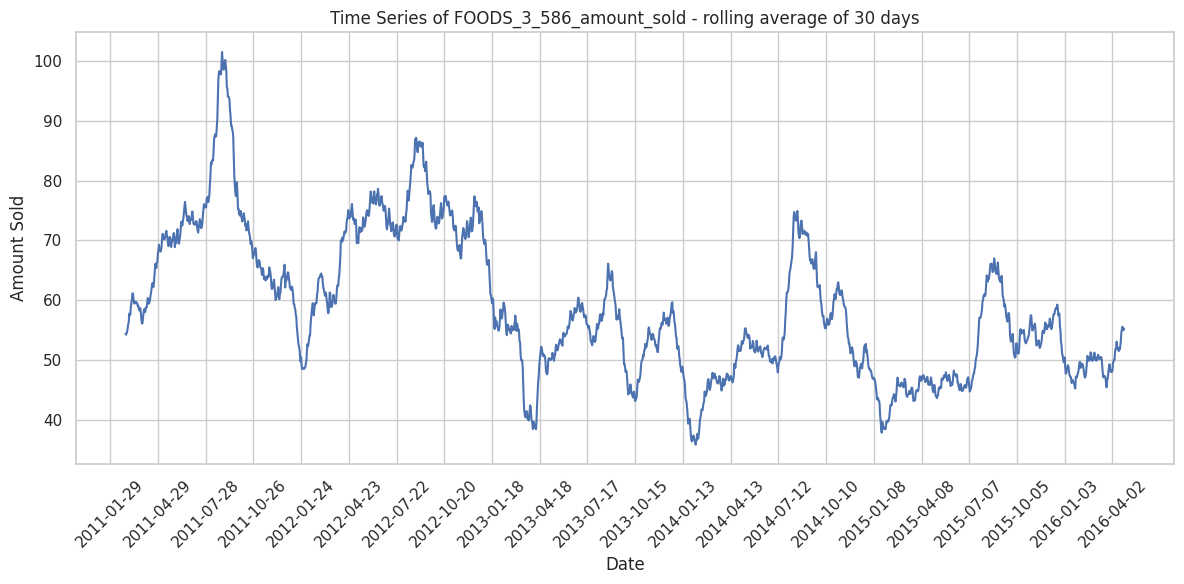

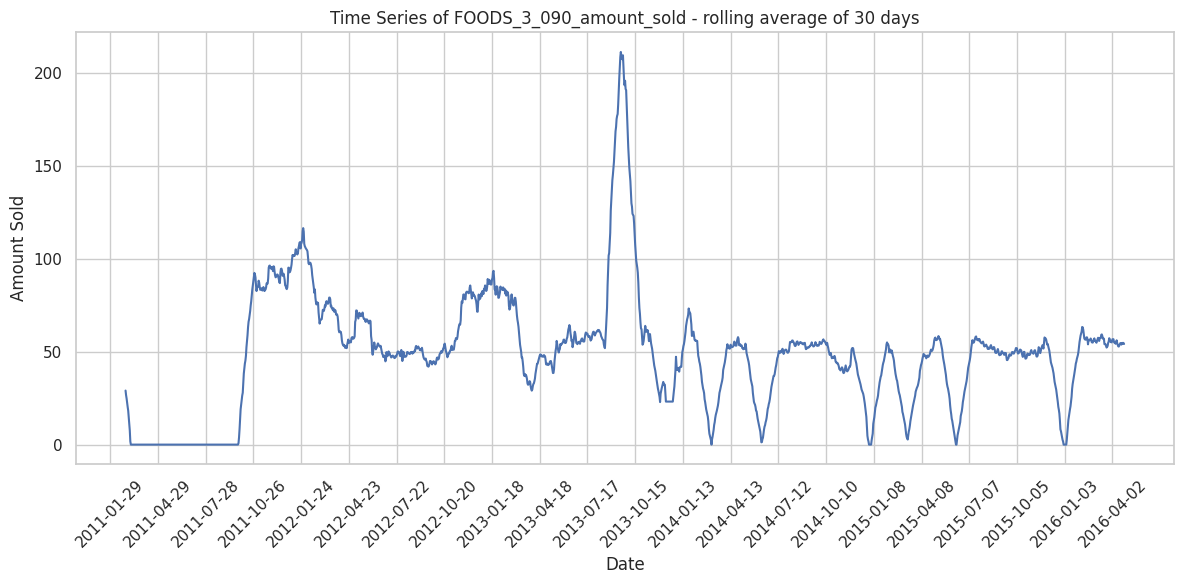

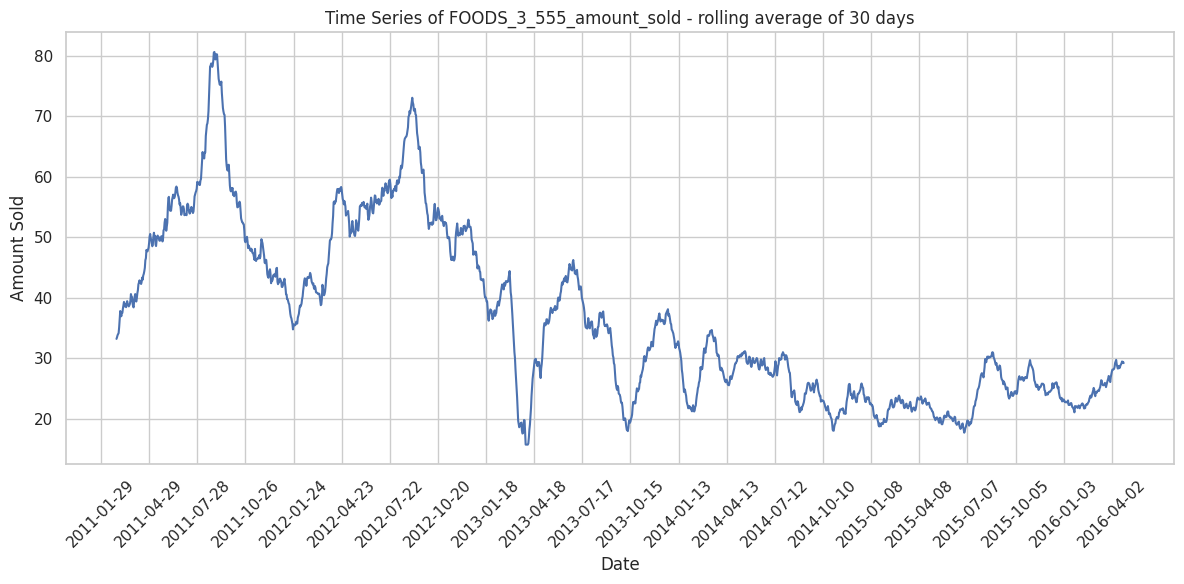

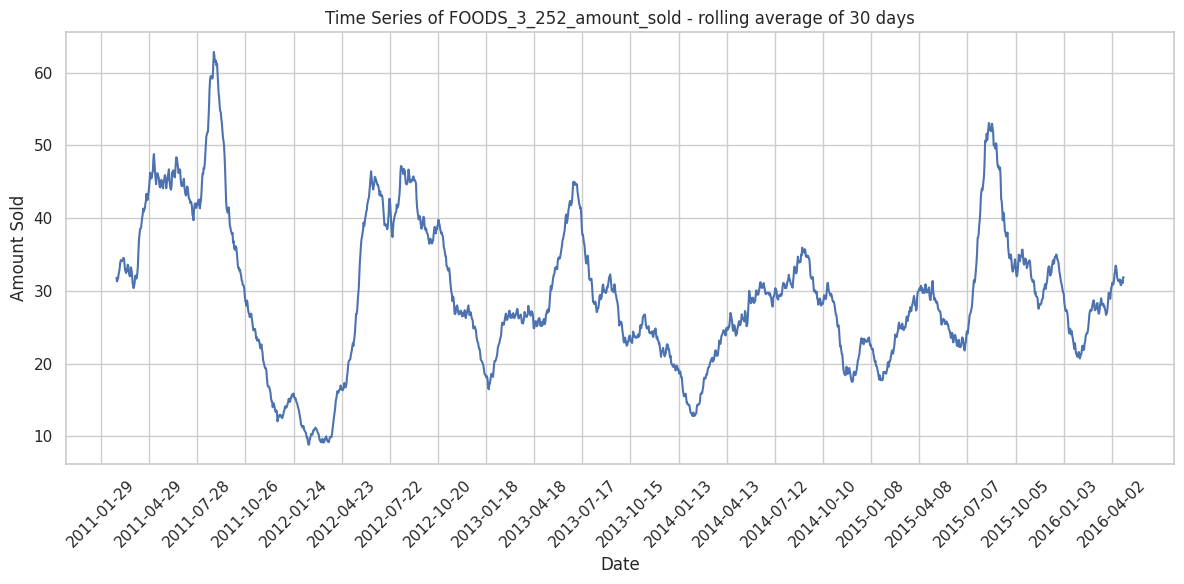

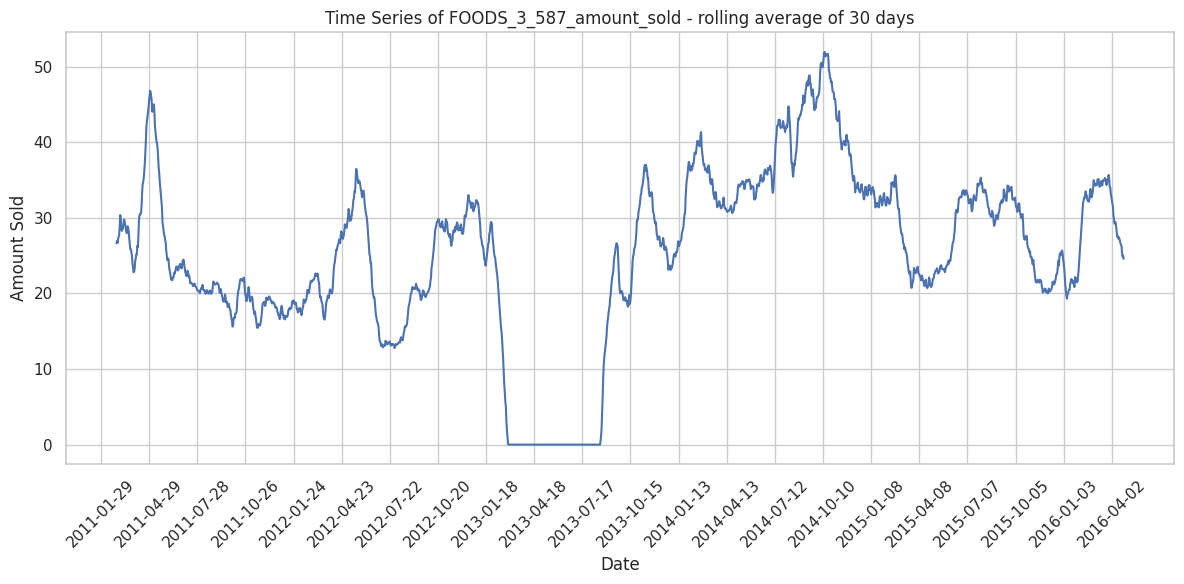

In [74]:
#visualise each variable
import os
fig_save_path = os.path.join('../reports/figures/rolling_avg_30')

if not os.path.exists(fig_save_path):
    os.makedirs(fig_save_path)

def generate_time_series_viz(df, col, rolling_average=30, save=True,save_path=None):

    plt.figure(figsize=(12, 6))

    df['rolling_avg'] = df[col].rolling(window=rolling_average).mean()
    

    sns.lineplot(data=df, x='date', y='rolling_avg')
    plt.title(f'Time Series of {col} - rolling average of {rolling_average} days')
    plt.xlabel('Date')
    plt.ylabel('Amount Sold')
    plt.xticks(rotation=45)
 
    #make spaced x ticks
    plt.xticks(np.arange(0, len(df['date']), step=90), rotation=45)
    plt.tight_layout()
    fig_name = f"{col}_raw_time_series_viz.png"
    save_path = os.path.join(fig_save_path, fig_name)
    if save == True:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    

for column in cols_of_interest:
    generate_time_series_viz(df=merged_df, 
                            col=column,
                            rolling_average=30,
                            save=True)


### checking trend and seasonality

In [86]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


def detect_trend(df, col, rolling_average=30):

    df['rolling_avg'] = df[col].rolling(window=rolling_average).mean()

    # Drop NaN values from the rolling average
    # valid_data = df.dropna(subset=['rolling_avg'])
    
    X = np.arange(len(df.index.values)).reshape(-1, 1)
    # y = valid_data['rolling_avg'].values.reshape(-1, 1)
    y = df[col].values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0][0]

    return slope

for column in cols_of_interest:

    trend_amount = detect_trend(df=merged_df, 
                                col=column,
                                rolling_average=30)

    print(f"Trend for {column}: {trend_amount:.4f}")
      





Trend for FOODS_3_586_amount_sold: -0.0128
Trend for FOODS_3_090_amount_sold: 0.0007
Trend for FOODS_3_555_amount_sold: -0.0198
Trend for FOODS_3_252_amount_sold: -0.0030
Trend for FOODS_3_587_amount_sold: 0.0063


### Check for seasonality

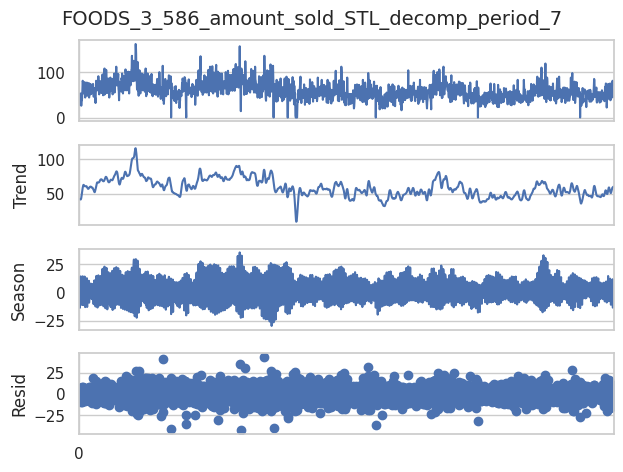

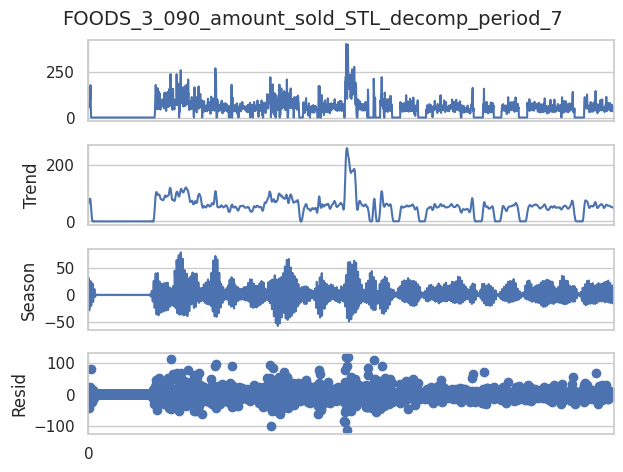

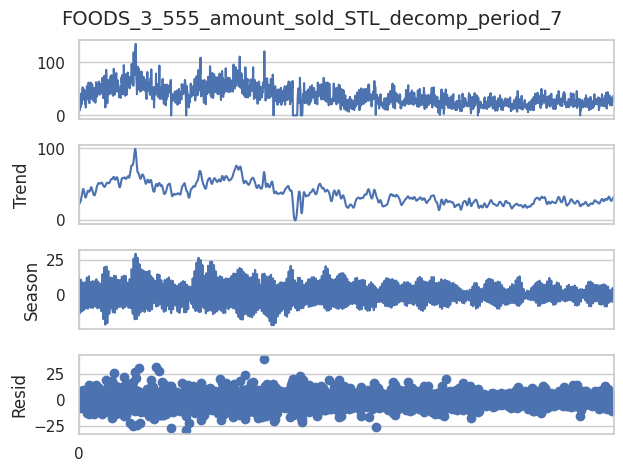

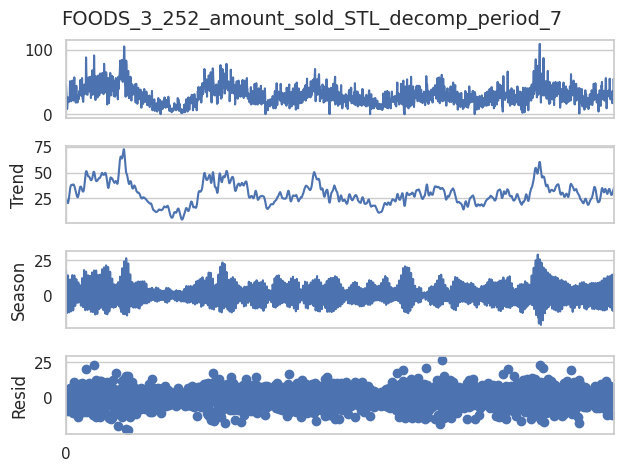

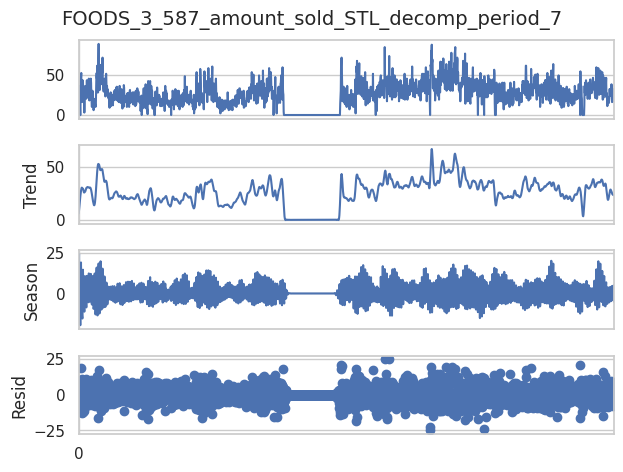

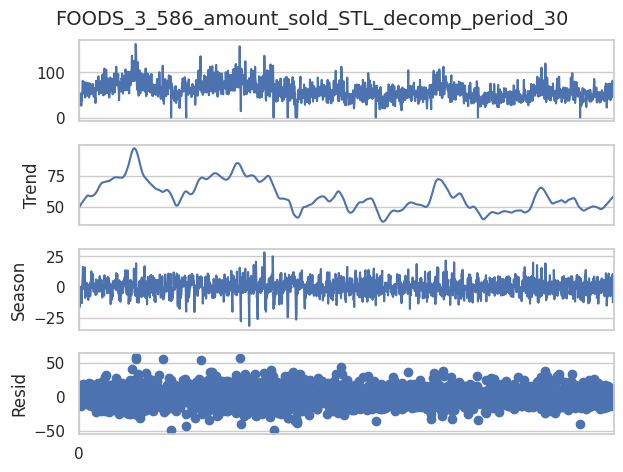

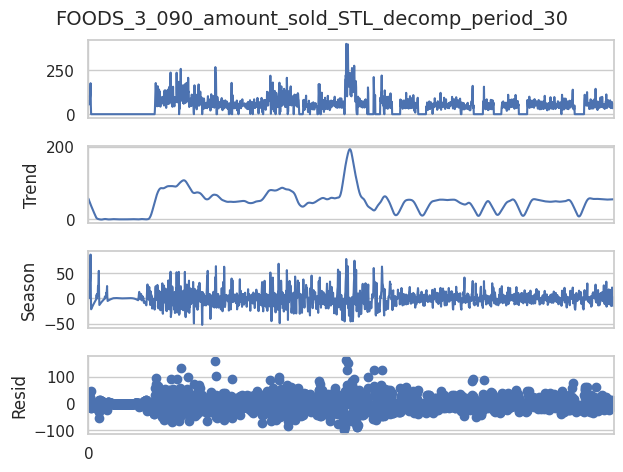

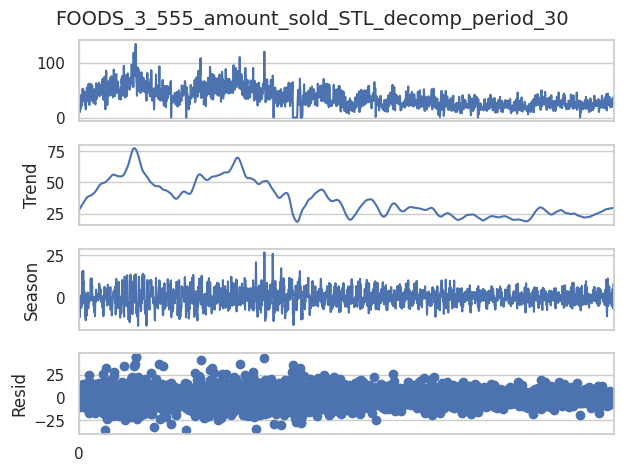

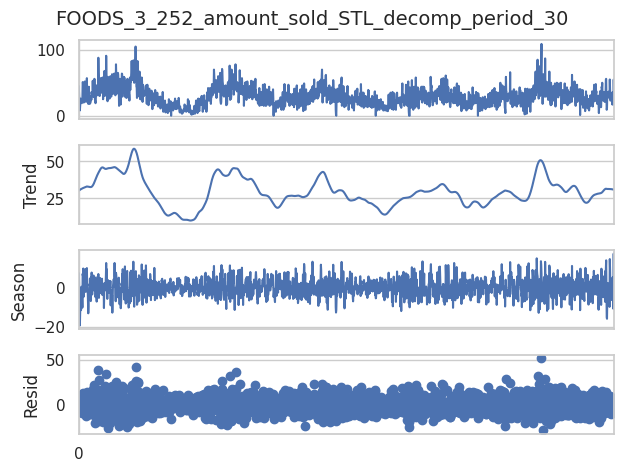

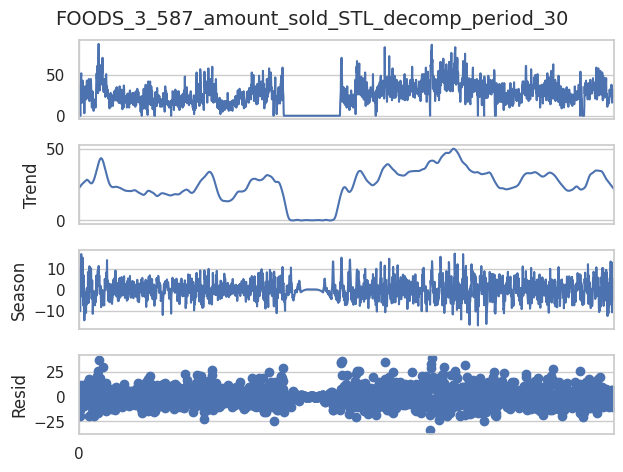

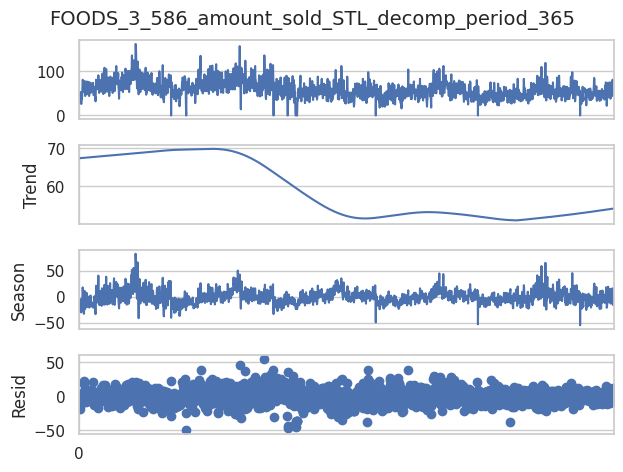

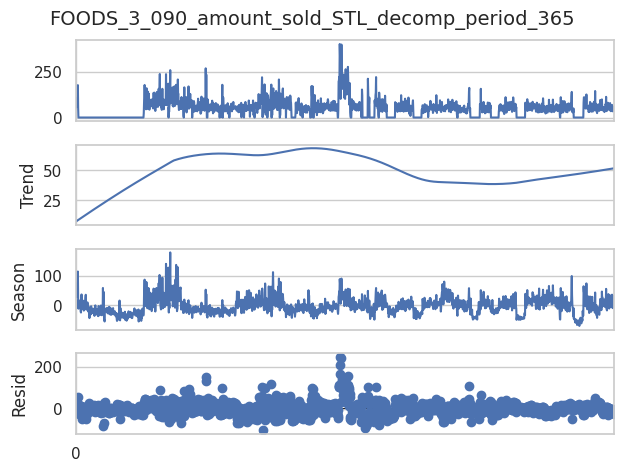

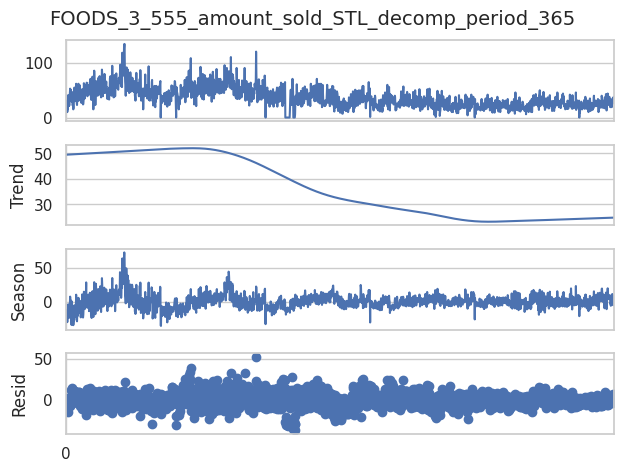

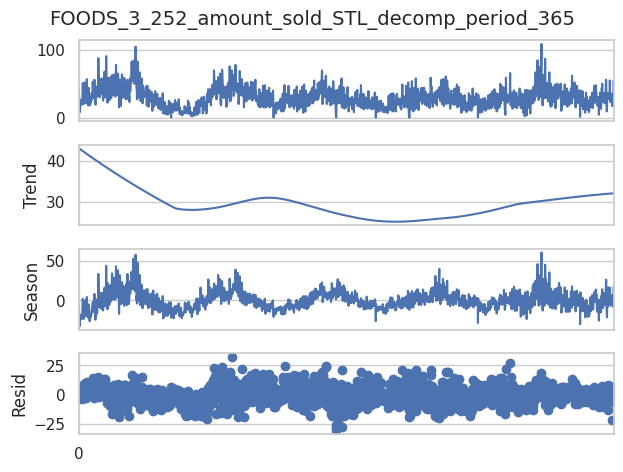

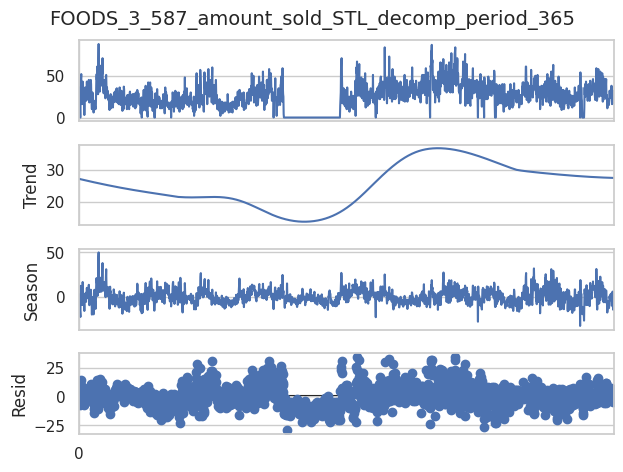

In [103]:
from statsmodels.tsa.seasonal import STL
import os

seasonality_fig_folder = os.path.join('../reports/figures/seasonality_check')

os.makedirs(seasonality_fig_folder, exist_ok=True)

def check_seasonality(df,col,period,save=True,save_path=None):
    # plt.title(f'Seasonality Check for {col} with period {period}')
    series = df[col]
    stl = STL(series, period=period)
    res = stl.fit()

    fig = res.plot()
    fig.suptitle(f"{col}_STL_decomp_period_{period}", fontsize=14)

    for ax in fig.axes:
        ax.set_title("")  # This removes the subplot titles
        ax.set_xticks(ax.get_xticks()[::60])

    

    save_path = os.path.join(seasonality_fig_folder, f"{col}_seasonality_check_period_{period}.png")
    if save == True:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

for seasonality in [7,30,365]:
    for column in cols_of_interest:
        check_seasonality(df=merged_df, 
                col=column,
                period=seasonality,
                save=True,
                save_path=seasonality_fig_folder)
        
        
            


### Inspect imputation process

In [ ]:
def generate_time_series_viz_raw(df, col1,col2 save=True,save_path=None):

    plt.figure(figsize=(12, 6))

    # df['rolling_avg'] = df[col].rolling(window=rolling_average).mean()
    

    sns.lineplot(data=df, x='date', y=col1)
    sns.lineplot(data=df, x='date', y=col2, color='orange')
    plt.title(f'{col}')
    plt.xlabel('Date')
    plt.ylabel('Amount Sold')
    plt.xticks(rotation=45)
 
    #make spaced x ticks
    plt.xticks(np.arange(0, len(df['date']), step=90), rotation=45)
    plt.tight_layout()
    fig_name = f"{col}_raw_time_series_viz.png"
    save_path = os.path.join(fig_save_path, fig_name)
    if save == True:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

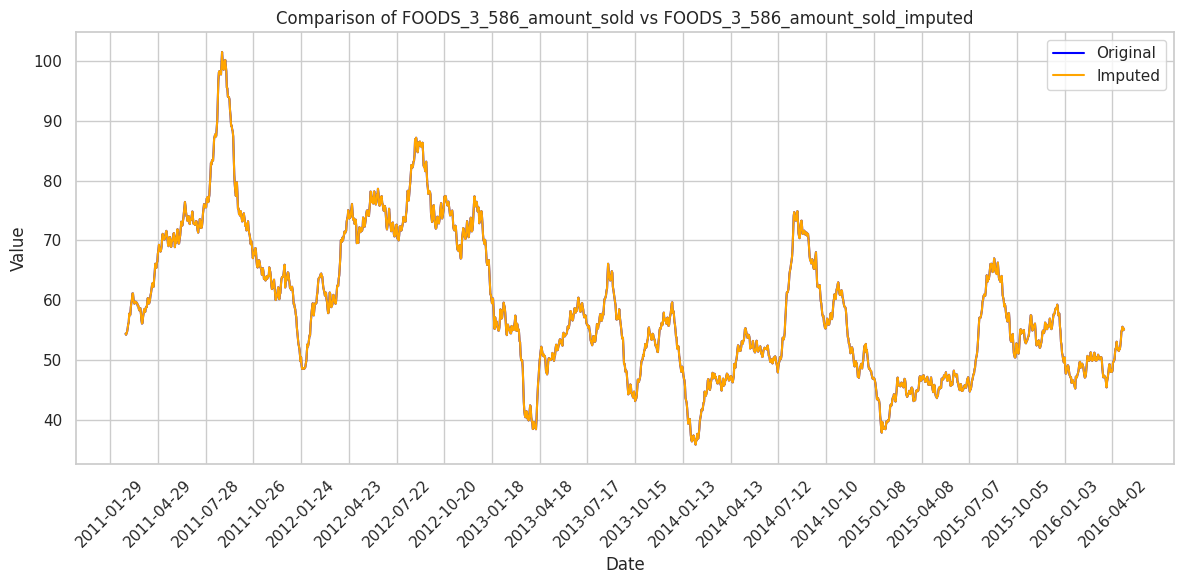

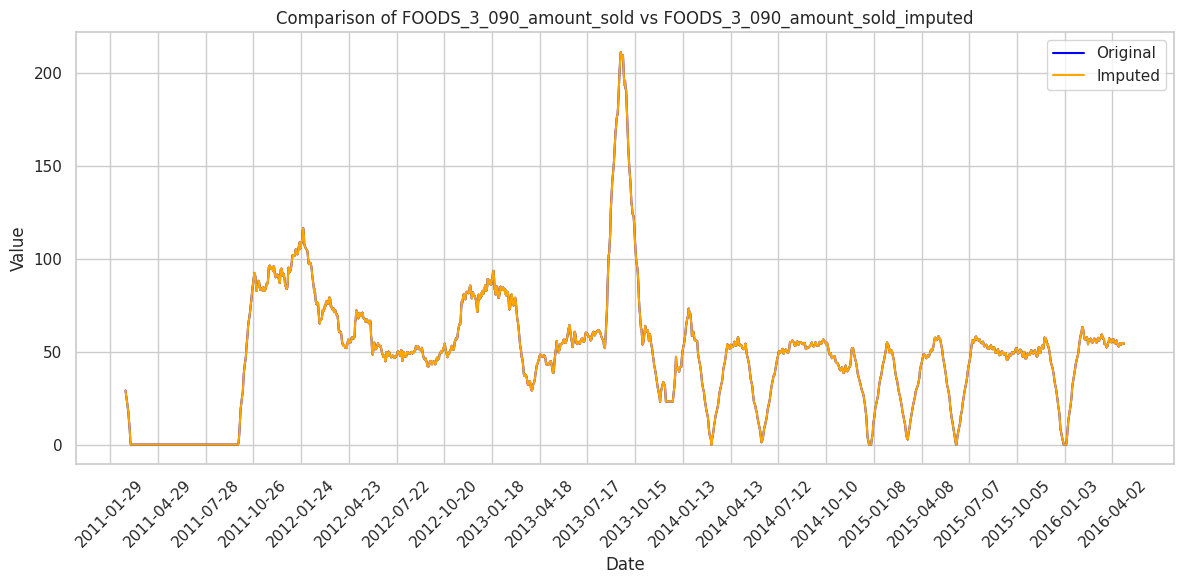

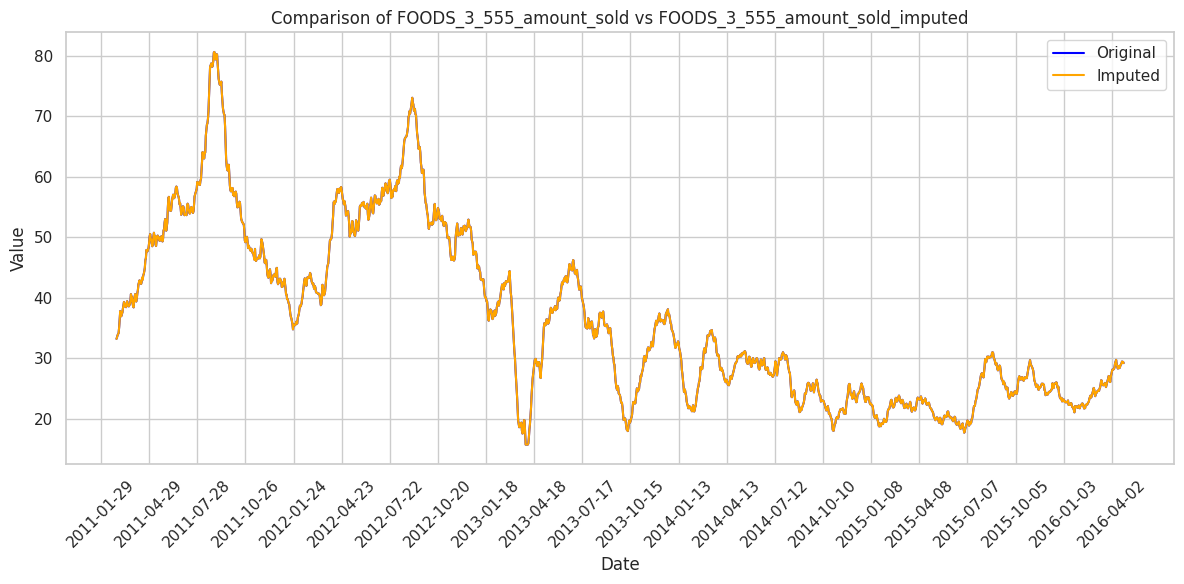

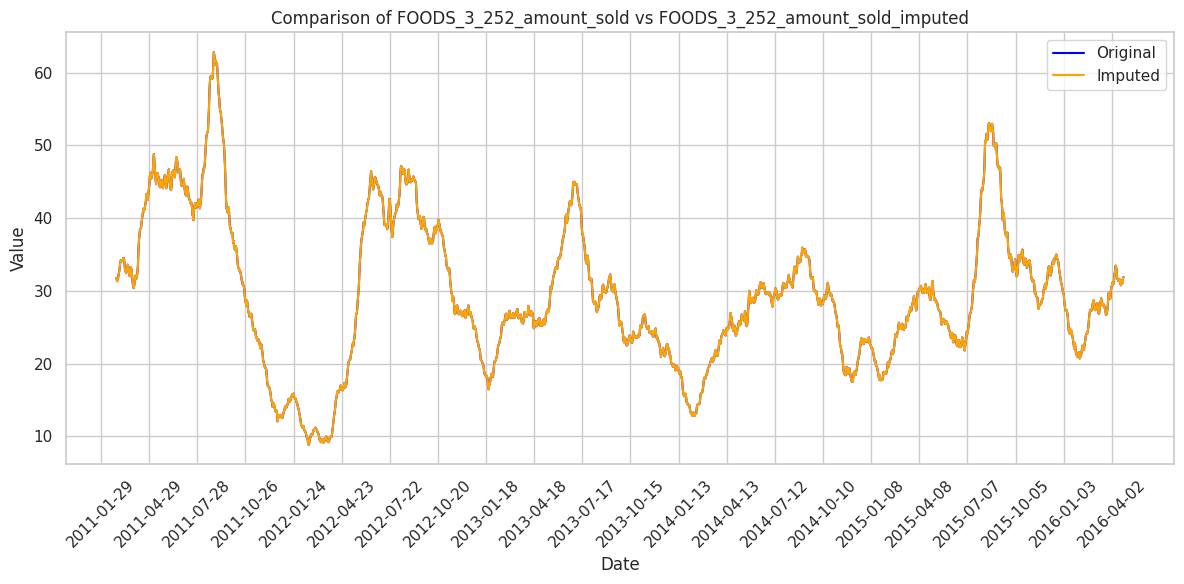

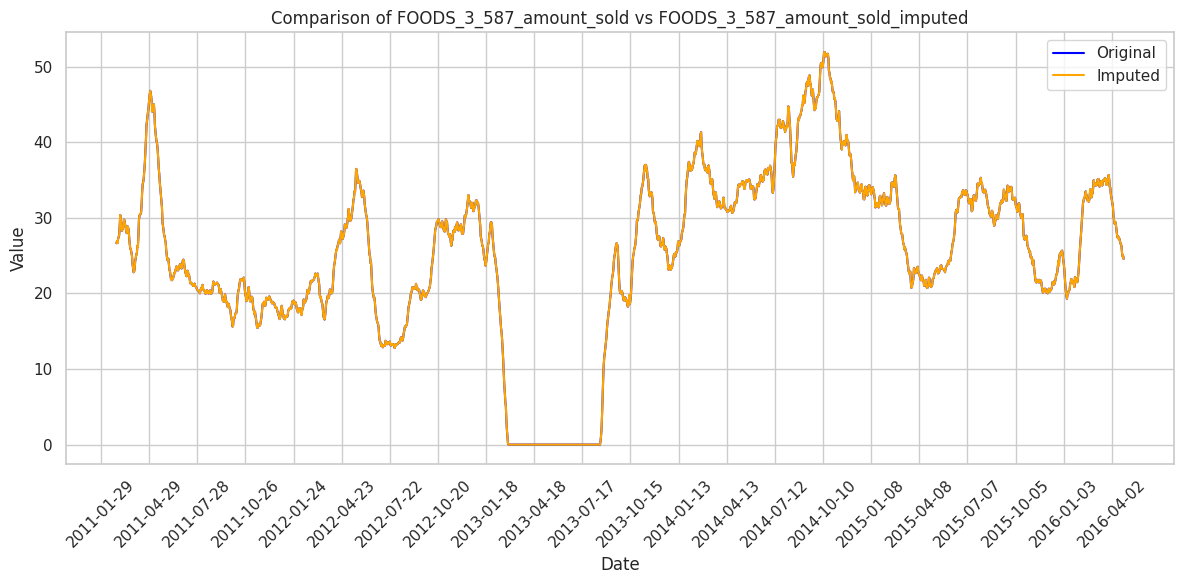

In [129]:
vars_of_interest = ['FOODS_3_586_amount_sold', 'FOODS_3_090_amount_sold',
       'FOODS_3_555_amount_sold', 'FOODS_3_252_amount_sold',
       'FOODS_3_587_amount_sold']

def compare_original_vs_imputed(df, original_col, imputed_col, x_col='date', save=True, save_path=None):
    """
    Generate a line plot comparing the original variable with its imputed version.

    Parameters:
    df (pd.DataFrame): The dataframe containing the data.
    original_col (str): The name of the original variable column.
    imputed_col (str): The name of the imputed variable column.
    x_col (str): The column to use as the x-axis (default is 'date').
    save (bool): Whether to save the plot as a file (default is True).
    save_path (str): The path to save the plot (default is None).
    """
    plt.figure(figsize=(12, 6))
    y1 = df[original_col].rolling(window=30).mean()
    y2 = df[imputed_col].rolling(window=30).mean()
    sns.lineplot(data=df, x=x_col, y=y1, label='Original', color='blue')
    sns.lineplot(data=df, x=x_col, y=y2, label='Imputed', color='orange')
    plt.title(f'Comparison of {original_col} vs {imputed_col}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.xticks(np.arange(0, len(df['date']), step=90), rotation=45)
    plt.legend()
    plt.tight_layout()

    if save:
        if save_path is None:
            save_path = f"{original_col}_vs_{imputed_col}_comparison.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

processed_df = pd.read_csv('../data/processed/tx1_top_5_long_engineered_processed.csv')

for var in vars_of_interest:
    
    compare_original_vs_imputed(
        df=processed_df,
        original_col=var,
        imputed_col=var+'_imputed',
        x_col='date',
        save=False,
        save_path='../reports/figures/FOODS_3_252_comparison.png'
    )



In [127]:
vars_of_interest = ['FOODS_3_586_amount_sold', 'FOODS_3_090_amount_sold',
       'FOODS_3_555_amount_sold', 'FOODS_3_252_amount_sold',
       'FOODS_3_587_amount_sold']

processed_df = pd.read_csv('../data/processed/tx1_top_5_long_engineered_processed.csv')

processed_df.columns

# for var in vars_of_interest:
    

Index(['Unnamed: 0.1', 'Unnamed: 0', 'date', 'FOODS_3_586_amount_sold',
       'FOODS_3_090_amount_sold', 'FOODS_3_555_amount_sold',
       'FOODS_3_252_amount_sold', 'FOODS_3_587_amount_sold', 'wm_yr_wk',
       'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1',
       'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI',
       'FOODS_3_090_sell_price', 'FOODS_3_252_sell_price',
       'FOODS_3_555_sell_price', 'FOODS_3_586_sell_price',
       'FOODS_3_587_sell_price', 'day_of_month', 'is_weekend',
       'is_public_holiday', 'days_to_next_holiday', 'wday_sin', 'wday_cos',
       'month_sin', 'month_cos', 'day_of_month_sin', 'day_of_month_cos',
       'FOODS_3_586_amount_sold_imputed', 'FOODS_3_090_amount_sold_imputed',
       'FOODS_3_555_amount_sold_imputed', 'FOODS_3_252_amount_sold_imputed',
       'FOODS_3_587_amount_sold_imputed'],
      dtype='object')

In [ ]:
# Visualize distributions of key variables
plt.figure(figsize=(12, 6))
sns.histplot(data['your_column_name'], bins=30, kde=True)
plt.title('Distribution of Your Column Name')
plt.xlabel('Your Column Name')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()